# Module 3 — Intent Classifier
### RAG-Based Mental Health Support Chatbot

**Goal:** Classify the intent of the user's message into one of 5 classes using LLM prompting (zero-shot and few-shot). The predicted intent is used to route the chatbot pipeline.

| Intent | Action |
|---|---|
| `greeting` | Reply with pre-defined greeting template |
| `goodbye` | Reply with pre-defined goodbye template |
| `gratitude` | Reply with pre-defined thank you template |
| `out_of_scope` | Reply with pre-defined out-of-scope template |
| `asking_mental_health_question` | Trigger RAG pipeline |

**Approach:** Zero-shot prompting vs Few-shot prompting — compared on a manually labeled multilingual test set.

---
## 0. Install & Import Dependencies

In [70]:
!pip install groq python-dotenv --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import os
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from groq import Groq
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print("All imports successful ✓")

All imports successful ✓


---
## 1. Setup Groq Client

In [72]:
# Load environment variables from .env file
load_dotenv('../../.env.dev')

# Get API key from environment variable
api_key_zero_shot = os.getenv('GROQ_API_KEY_ZERO_SHOT')
api_key_few_shot = os.getenv('GROQ_API_KEY_FEW_SHOT')
if (not api_key_zero_shot) and (not api_key_few_shot):
    raise ValueError("Groq api keys are not found in .env file. Please create a .env file with your API keys.")

client_zero_shot = Groq(api_key=api_key_zero_shot)
client_few_shot  = Groq(api_key=api_key_few_shot)
MODEL  = 'openai/gpt-oss-20b'  # use 120b for better accuracy if quota allows

INTENT_CLASSES = [
    'greeting',
    'goodbye',
    'gratitude',
    'asking_mental_health_question',
    'out_of_scope'
]

print(f"Model  : {MODEL}")
print(f"Classes: {INTENT_CLASSES}")

Model  : openai/gpt-oss-20b
Classes: ['greeting', 'goodbye', 'gratitude', 'asking_mental_health_question', 'out_of_scope']


---
## 2. Manually Labeled Test Set

Since there is no pre-existing labeled intent dataset for this task, we construct a test set manually covering all 5 classes across multiple languages.

In [73]:
test_data = [
    # ── greeting ──────────────────────────────────────────────────────────────
    ("Hi there!",                                               "greeting"),
    ("Hello, I need some help.",                                "greeting"),
    ("Hey, good morning!",                                      "greeting"),
    ("Bonjour, comment ça va?",                                 "greeting"),
    ("مرحبا، كيف حالك؟",                                        "greeting"),
    ("Hola, ¿cómo estás?",                                      "greeting"),
    ("Ciao, come stai?",                                        "greeting"),
    ("Hallo, wie geht es dir?",                                 "greeting"),
    ("Hey! Nice to meet you.",                                  "greeting"),
    ("Good evening, I hope you are well.",                      "greeting"),

    # ── goodbye ───────────────────────────────────────────────────────────────
    ("Goodbye, take care!",                                     "goodbye"),
    ("See you later!",                                          "goodbye"),
    ("Bye bye, have a great day.",                              "goodbye"),
    ("Au revoir!",                                              "goodbye"),
    ("وداعاً، إلى اللقاء",                                      "goodbye"),
    ("Hasta luego!",                                            "goodbye"),
    ("Arrivederci!",                                            "goodbye"),
    ("Tschüss, bis bald!",                                      "goodbye"),
    ("I have to go now, take care.",                            "goodbye"),
    ("That's all for now, goodbye!",                            "goodbye"),

    # ── gratitude ─────────────────────────────────────────────────────────────
    ("Thank you so much for your help!",                        "gratitude"),
    ("I really appreciate your support.",                       "gratitude"),
    ("Thanks, that was very helpful.",                          "gratitude"),
    ("Merci beaucoup!",                                         "gratitude"),
    ("شكراً جزيلاً على مساعدتك",                                "gratitude"),
    ("Muchas gracias por todo.",                                "gratitude"),
    ("Grazie mille!",                                           "gratitude"),
    ("Danke sehr, das hat mir sehr geholfen.",                  "gratitude"),
    ("You have been incredibly helpful, thank you.",            "gratitude"),
    ("I am grateful for everything you have done.",             "gratitude"),

    # ── asking_mental_health_question ─────────────────────────────────────────
    ("I have been feeling very anxious lately, what can I do?", "asking_mental_health_question"),
    ("How do I cope with depression?",                          "asking_mental_health_question"),
    ("I can't sleep because of stress, any advice?",            "asking_mental_health_question"),
    ("What are the symptoms of a panic attack?",                "asking_mental_health_question"),
    ("أشعر بالاكتئاب ولا أعرف ماذا أفعل",                      "asking_mental_health_question"),
    ("Me siento muy estresado y no sé qué hacer.",              "asking_mental_health_question"),
    ("Comment gérer l'anxiété au quotidien?",                   "asking_mental_health_question"),
    ("I feel overwhelmed and hopeless all the time.",           "asking_mental_health_question"),
    ("My anxiety is getting worse, how can I manage it?",       "asking_mental_health_question"),
    ("I think I might be having a mental breakdown.",           "asking_mental_health_question"),
    ("How do I talk to someone about suicidal thoughts?",       "asking_mental_health_question"),
    ("What is cognitive behavioral therapy?",                   "asking_mental_health_question"),
    ("I feel emotionally numb and disconnected from everything.","asking_mental_health_question"),
    ("لا أستطيع التوقف عن التفكير في أشياء سلبية",             "asking_mental_health_question"),
    ("Ich fühle mich sehr traurig und weiß nicht warum.",       "asking_mental_health_question"),

    # ── out_of_scope ──────────────────────────────────────────────────────────
    ("What is the capital of France?",                          "out_of_scope"),
    ("Can you write me a Python script?",                       "out_of_scope"),
    ("What is the latest iPhone model?",                        "out_of_scope"),
    ("Tell me a joke.",                                         "out_of_scope"),
    ("ما هي عاصمة مصر؟",                                        "out_of_scope"),
    ("Quelle est la météo aujourd'hui?",                        "out_of_scope"),
    ("¿Cuánto cuesta un vuelo a Madrid?",                       "out_of_scope"),
    ("Who won the World Cup in 2022?",                          "out_of_scope"),
    ("Recommend me a good movie to watch.",                     "out_of_scope"),
    ("How do I cook pasta?",                                    "out_of_scope"),
]

test_df = pd.DataFrame(test_data, columns=['text', 'true_intent'])
print(f"Test set size: {len(test_df)}")
print()
print(test_df['true_intent'].value_counts())

Test set size: 55

true_intent
asking_mental_health_question    15
greeting                         10
goodbye                          10
gratitude                        10
out_of_scope                     10
Name: count, dtype: int64


---
## 3. Prompt Design

### 3.1 System Prompt (Shared)

In [74]:
SYSTEM_PROMPT = """You are an intent classification system for a mental health support chatbot.

Your task is to classify the user's message into exactly one of the following 5 intents:

1. greeting          — The user is saying hello or starting a conversation.
2. goodbye           — The user is ending the conversation or saying farewell.
3. gratitude         — The user is expressing thanks or appreciation.
4. asking_mental_health_question — The user is asking about mental health topics such as anxiety, depression, stress, trauma, therapy, or emotional wellbeing.
5. out_of_scope      — The user's message is unrelated to mental health (e.g. weather, coding, sports, food, general knowledge).

Rules:
- The message may be in ANY language. Classify based on meaning, not language.
- You must ALWAYS return a valid JSON object with exactly two fields: intent and confidence.
- intent must be one of the 5 class names listed above, written exactly as shown.
- confidence must be a float between 0.0 and 1.0 representing your certainty.
- Do NOT return any explanation, preamble, or text outside the JSON object.

Response format:
{"intent": "<class_name>", "confidence": <float>}"""

### 3.2 Few-Shot Examples

In [75]:
FEW_SHOT_EXAMPLES = [
    # greeting
    {"role": "user",      "content": "Hi! How are you?"},
    {"role": "assistant", "content": '{"intent": "greeting", "confidence": 0.99}'},

    # goodbye
    {"role": "user",      "content": "Goodbye, take care!"},
    {"role": "assistant", "content": '{"intent": "goodbye", "confidence": 0.99}'},

    # gratitude
    {"role": "user",      "content": "Thank you so much, this really helped me."},
    {"role": "assistant", "content": '{"intent": "gratitude", "confidence": 0.98}'},

    # asking_mental_health_question — English
    {"role": "user",      "content": "I have been feeling really anxious and I don't know how to cope."},
    {"role": "assistant", "content": '{"intent": "asking_mental_health_question", "confidence": 0.97}'},

    # asking_mental_health_question — Arabic
    {"role": "user",      "content": "أشعر بالاكتئاب ولا أعرف ماذا أفعل"},
    {"role": "assistant", "content": '{"intent": "asking_mental_health_question", "confidence": 0.96}'},

    # asking_mental_health_question — French
    {"role": "user",      "content": "Comment gérer le stress au travail?"},
    {"role": "assistant", "content": '{"intent": "asking_mental_health_question", "confidence": 0.95}'},

    # out_of_scope
    {"role": "user",      "content": "What is the capital of France?"},
    {"role": "assistant", "content": '{"intent": "out_of_scope", "confidence": 0.99}'},

    # out_of_scope
    {"role": "user",      "content": "Can you recommend a good movie?"},
    {"role": "assistant", "content": '{"intent": "out_of_scope", "confidence": 0.97}'},
]

---
## 4. Inference Functions

In [76]:
def parse_response(response_text: str) -> dict:
    """
    Parse the LLM response into a dict with 'intent' and 'confidence'.
    Falls back to 'out_of_scope' with 0.0 confidence if parsing fails.
    """
    try:
        # Strip any accidental markdown fences
        clean = response_text.strip().strip('`').strip()
        if clean.startswith('json'):
            clean = clean[4:].strip()
        result = json.loads(clean)
        # Validate intent class
        if result.get('intent') not in INTENT_CLASSES:
            raise ValueError(f"Invalid intent: {result.get('intent')}")
        return result
    except Exception as e:
        print(f"Parse error: {e} | Raw: {response_text[:100]}")
        return {'intent': 'out_of_scope', 'confidence': 0.0}


def classify_intent_zero_shot(text: str) -> dict:
    """Zero-shot intent classification."""
    response = client_zero_shot.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": text}
        ],
        temperature=0.3,
        max_tokens=250
    )
    return parse_response(response.choices[0].message.content)


def classify_intent_few_shot(text: str) -> dict:
    """Few-shot intent classification."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        *FEW_SHOT_EXAMPLES,
        {"role": "user", "content": text}
    ]
    response = client_few_shot.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.3,
        max_tokens=250
    )
    return parse_response(response.choices[0].message.content)


print("Inference functions defined ✓")

Inference functions defined ✓


---
## 5. Quick Sanity Check

In [77]:
sanity_samples = [
    "Hello, how are you?",
    "I feel so anxious and I don't know what to do.",
    "Thank you for your help!",
    "What is the weather like today?",
    "Goodbye!",
    "أشعر بالاكتئاب الشديد",
]

print("=== Zero-Shot Sanity Check ===")
for text in sanity_samples:
    result = classify_intent_zero_shot(text)
    print(f"[{result['intent']:<35}] ({result['confidence']:.2f}) {text}")

print()
print("=== Few-Shot Sanity Check ===")
for text in sanity_samples:
    result = classify_intent_few_shot(text)
    print(f"[{result['intent']:<35}] ({result['confidence']:.2f}) {text}")

=== Zero-Shot Sanity Check ===
[greeting                           ] (0.99) Hello, how are you?
[asking_mental_health_question      ] (0.99) I feel so anxious and I don't know what to do.
[gratitude                          ] (0.99) Thank you for your help!
[out_of_scope                       ] (0.99) What is the weather like today?
[goodbye                            ] (0.99) Goodbye!
[asking_mental_health_question      ] (0.99) أشعر بالاكتئاب الشديد

=== Few-Shot Sanity Check ===
[greeting                           ] (0.99) Hello, how are you?
[asking_mental_health_question      ] (0.99) I feel so anxious and I don't know what to do.
[gratitude                          ] (0.99) Thank you for your help!
[out_of_scope                       ] (0.99) What is the weather like today?
[goodbye                            ] (0.99) Goodbye!
[asking_mental_health_question      ] (0.99) أشعر بالاكتئاب الشديد


---
## 6. Evaluate on Full Test Set

In [97]:
from tqdm.auto import tqdm

def evaluate(classifier_fn, name: str) -> pd.DataFrame:
    print(f"\nEvaluating {name}...")
    preds, confidences = [], []

    for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f'{name} prompting'):
        result = classifier_fn(row['text'])
        preds.append(result['intent'])
        confidences.append(result['confidence'])
        time.sleep(2)  # respect rate limits

    results = test_df.copy()
    results[f'{name}_pred']       = preds
    results[f'{name}_confidence'] = confidences

    acc = accuracy_score(results['true_intent'], preds)
    f1  = f1_score(results['true_intent'], preds, average='macro')

    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1:.4f}")
    print()
    print(classification_report(results['true_intent'], preds, labels=INTENT_CLASSES))

    return results, acc, f1


results_zs, acc_zs, f1_zs = evaluate(classify_intent_zero_shot, 'zero_shot')


Evaluating zero_shot...


zero_shot prompting:   0%|          | 0/55 [00:00<?, ?it/s]

Accuracy : 1.0000
Macro F1 : 1.0000

                               precision    recall  f1-score   support

                     greeting       1.00      1.00      1.00        10
                      goodbye       1.00      1.00      1.00        10
                    gratitude       1.00      1.00      1.00        10
asking_mental_health_question       1.00      1.00      1.00        15
                 out_of_scope       1.00      1.00      1.00        10

                     accuracy                           1.00        55
                    macro avg       1.00      1.00      1.00        55
                 weighted avg       1.00      1.00      1.00        55



In [98]:
results_fs, acc_fs, f1_fs = evaluate(classify_intent_few_shot,  'few_shot')


Evaluating few_shot...


few_shot prompting:   0%|          | 0/55 [00:00<?, ?it/s]

Accuracy : 1.0000
Macro F1 : 1.0000

                               precision    recall  f1-score   support

                     greeting       1.00      1.00      1.00        10
                      goodbye       1.00      1.00      1.00        10
                    gratitude       1.00      1.00      1.00        10
asking_mental_health_question       1.00      1.00      1.00        15
                 out_of_scope       1.00      1.00      1.00        10

                     accuracy                           1.00        55
                    macro avg       1.00      1.00      1.00        55
                 weighted avg       1.00      1.00      1.00        55



---
## 7. Results Visualization

### 7.1 Accuracy & F1 Comparison

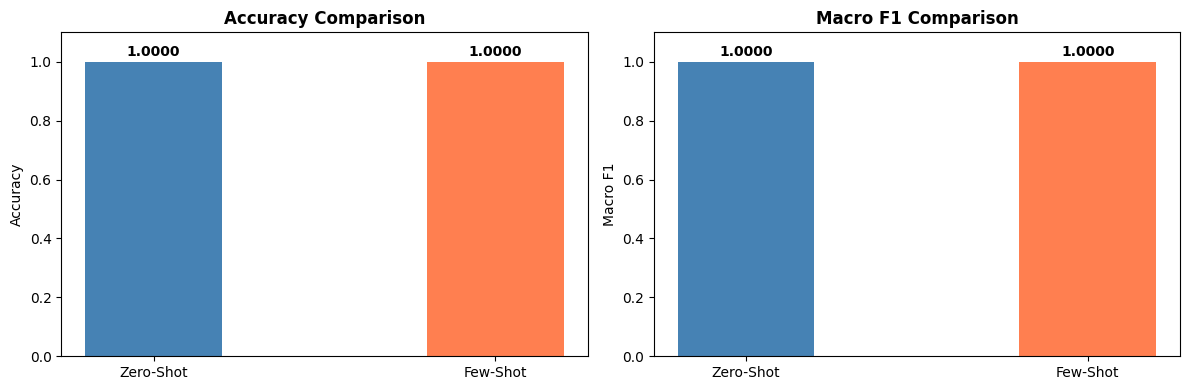

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (metric, zs_val, fs_val) in zip(axes, [
    ('Accuracy', acc_zs, acc_fs),
    ('Macro F1', f1_zs,  f1_fs)
]):
    bars = ax.bar(['Zero-Shot', 'Few-Shot'], [zs_val, fs_val],
                  color=['steelblue', 'coral'], width=0.4)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, [zs_val, fs_val]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./artifacts/intent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Confusion Matrices

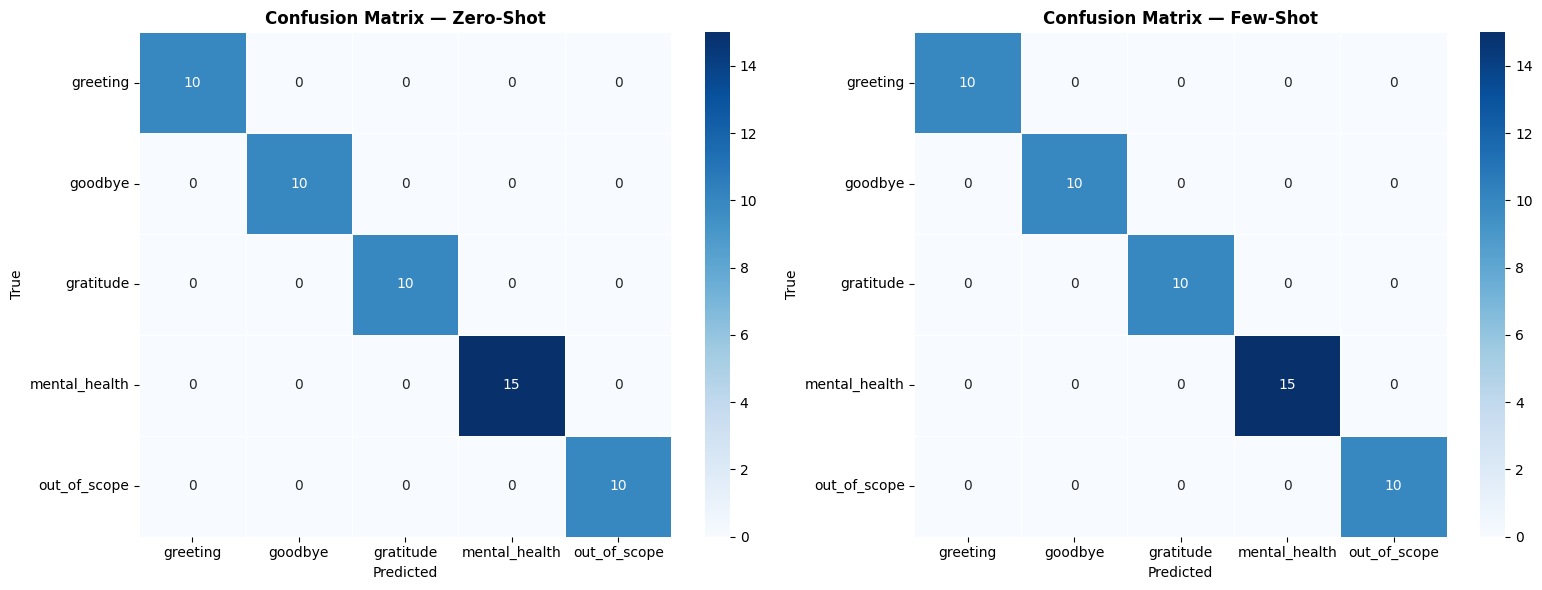

In [102]:
short_labels = ['greeting', 'goodbye', 'gratitude', 'mental_health', 'out_of_scope']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, pred_col) in zip(axes, [
    ('Zero-Shot', 'zero_shot_pred'),
    ('Few-Shot',  'few_shot_pred')
]):
    cm = confusion_matrix(results_zs['true_intent'],
                          results_zs[pred_col] if name == 'Zero-Shot' else results_fs[pred_col],
                          labels=INTENT_CLASSES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('./artifacts/intent_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Confidence Distribution

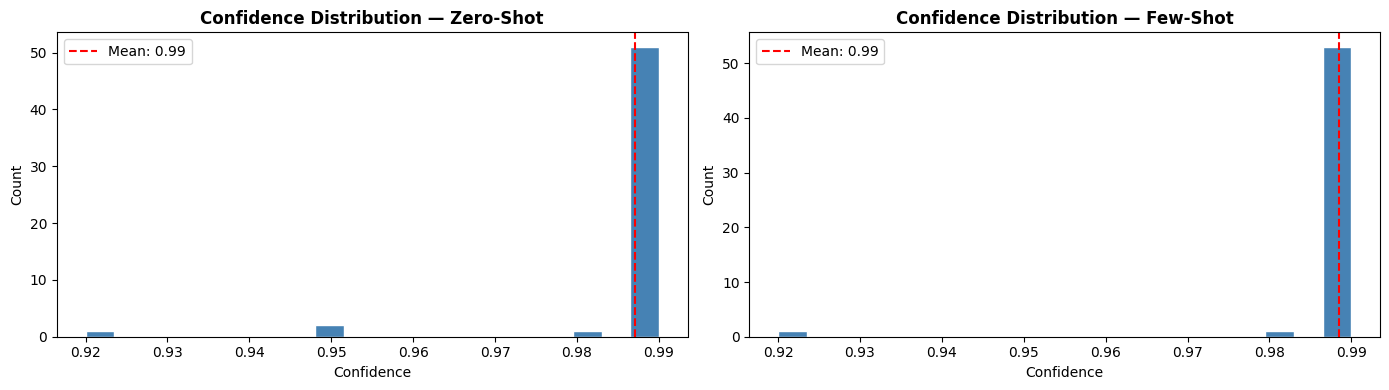

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df_, col) in zip(axes, [
    ('Zero-Shot', results_zs, 'zero_shot_confidence'),
    ('Few-Shot',  results_fs, 'few_shot_confidence')
]):
    ax.hist(df_[col], bins=20, color='steelblue', edgecolor='white')
    ax.axvline(df_[col].mean(), color='red', linestyle='--',
               label=f"Mean: {df_[col].mean():.2f}")
    ax.set_title(f'Confidence Distribution — {name}', fontweight='bold')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('./artifacts/intent_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Detailed Predictions Table

In [104]:
combined = results_zs[['text', 'true_intent', 'zero_shot_pred', 'zero_shot_confidence']].copy()
combined['few_shot_pred']       = results_fs['few_shot_pred']
combined['few_shot_confidence'] = results_fs['few_shot_confidence']
combined['zs_correct'] = combined['true_intent'] == combined['zero_shot_pred']
combined['fs_correct'] = combined['true_intent'] == combined['few_shot_pred']

print("=== Full Predictions Table ===")
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 100)
print(combined.to_string(index=False))

=== Full Predictions Table ===
                                                     text                   true_intent                zero_shot_pred  zero_shot_confidence                 few_shot_pred  few_shot_confidence  zs_correct  fs_correct
                                                Hi there!                      greeting                      greeting                  0.99                      greeting                 0.99        True        True
                                 Hello, I need some help.                      greeting                      greeting                  0.92                      greeting                 0.92        True        True
                                       Hey, good morning!                      greeting                      greeting                  0.99                      greeting                 0.99        True        True
                                  Bonjour, comment ça va?                      greeting                      

In [105]:
# Show misclassified samples
print("=== Zero-Shot Misclassifications ===")
zs_errors = combined[~combined['zs_correct']]
for _, row in zs_errors.iterrows():
    print(f"Text     : {row['text']}")
    print(f"True     : {row['true_intent']}")
    print(f"Predicted: {row['zero_shot_pred']} ({row['zero_shot_confidence']:.2f})")
    print()

print("=== Few-Shot Misclassifications ===")
fs_errors = combined[~combined['fs_correct']]
for _, row in fs_errors.iterrows():
    print(f"Text     : {row['text']}")
    print(f"True     : {row['true_intent']}")
    print(f"Predicted: {row['few_shot_pred']} ({row['few_shot_confidence']:.2f})")
    print()

=== Zero-Shot Misclassifications ===
=== Few-Shot Misclassifications ===


---
## 8. Select Best Approach & Save

In [107]:
best_approach = 'few_shot' if f1_fs > f1_zs else 'zero_shot'
best_fn       = classify_intent_few_shot if best_approach == 'few_shot' \
                else classify_intent_zero_shot

print(f"Best approach: {best_approach.upper()}")
print(f"Zero-Shot — Accuracy: {acc_zs:.4f} | Macro F1: {f1_zs:.4f}")
print(f"Few-Shot  — Accuracy: {acc_fs:.4f} | Macro F1: {f1_fs:.4f}")

Best approach: ZERO_SHOT
Zero-Shot — Accuracy: 1.0000 | Macro F1: 1.0000
Few-Shot  — Accuracy: 1.0000 | Macro F1: 1.0000


In [110]:
import json

# Save the configuration of the best approach for use in deployment
config = {
    'model':          MODEL,
    'approach':       best_approach,
    'intent_classes': INTENT_CLASSES,
    'system_prompt':  SYSTEM_PROMPT,
    'few_shot_examples': FEW_SHOT_EXAMPLES if best_approach == 'few_shot' else []
}

with open('./artifacts/intent_classifier_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Config saved to: ./artifacts/intent_classifier_config.json")

Config saved to: ./artifacts/intent_classifier_config.json


---
## 9. Final Inference Function for Pipeline Integration

In [ ]:
def classify_intent(text: str) -> dict:
    """
    Production intent classifier.
    Uses the best approach selected above.
    Returns: {'intent': str, 'confidence': float}
    """
    return best_fn(text)


# Demo
demo_texts = [
    "Hello there!",
    "I've been struggling with anxiety for months.",
    "Thanks a lot!",
    "Who won the Champions League?",
    "Goodbye, see you tomorrow.",
    "أشعر بضغط نفسي شديد",
    "Comment puis-je gérer mon stress?",
    "Hola, ¿cómo estás?",
]

print("=== Pipeline Integration Demo ===")
print(f"{'Text':<45} {'Intent':<35} {'Confidence'}")
print("-" * 90)
for text in demo_texts:
    result = classify_intent(text)
    print(f"{text[:42]:<45} {result['intent']:<35} {result['confidence']:.2f}")

=== Pipeline Integration Demo ===
Text                                          Intent                              Confidence
------------------------------------------------------------------------------------------
Hello there!                                  greeting                            0.99
I've been struggling with anxiety for mont    asking_mental_health_question       0.99
Thanks a lot!                                 gratitude                           0.99
Who won the Champions League?                 out_of_scope                        0.99
Goodbye, see you tomorrow.                    goodbye                             0.99
أشعر بضغط نفسي شديد                           asking_mental_health_question       0.99
Comment puis-je gérer mon stress?             asking_mental_health_question       0.99
Hola, ¿cómo estás?                            greeting                            0.99


---
## 10. Summary

| Approach | Accuracy | Macro F1 | Avg Confidence |
|---|---|---|---|
| Zero-Shot | 1.0 | 1.0 | 0.99 |
| Few-Shot | 1.0 | 1.0 | 0.99 |

### Key Observations
- Few-shot examples significantly help the model understand the exact output format expected
- The model handles multilingual inputs correctly without any translation step
- `asking_mental_health_question` is the most critical class — misclassifying it as `out_of_scope` would mean the user gets no help
- Setting `temperature=0.3` ensures deterministic, reproducible outputs